In [59]:
import warnings
import itertools
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import pandas as pd

import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
matplotlib.rcParams['axes.labelsize']=14
matplotlib.rcParams['xtick.labelsize']=12
matplotlib.rcParams['ytick.labelsize']=12
matplotlib.rcParams['text.color']='k'

In [60]:
df = pd.read_csv(r"C:\Users\samriddhiashoksingh\Downloads\SBI_Historical_Data.csv")

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,"Aug 07, 2020",190.65,191.45,192.10,189.55,44.82M,-0.16%
1,"Aug 06, 2020",190.95,192.30,194.50,190.25,59.74M,-0.26%
2,"Aug 05, 2020",191.45,192.75,196.85,191.00,68.89M,-0.08%
3,"Aug 04, 2020",191.60,193.35,193.80,190.50,43.87M,-0.34%
4,"Aug 03, 2020",192.25,192.00,194.60,190.05,72.46M,0.42%


In [61]:
df.shape

(1385, 7)

In [62]:
df.describe()

,Price,Open,High,Low
count,1385.000000,1385.000000,1385.000000,1385.000000
mean,266.274404,266.903213,270.343682,262.757906
std,45.555277,45.590664,45.829745,45.248334
min,150.850000,151.950000,153.200000,148.250000
25%,245.650000,245.900000,248.800000,242.550000
50%,270.800000,271.150000,274.600000,267.400000
75%,296.150000,296.500000,300.750000,292.200000
max,372.400000,371.950000,373.800000,366.200000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1385 non-null   object 
 1   Price     1385 non-null   float64
 2   Open      1385 non-null   float64
 3   High      1385 non-null   float64
 4   Low       1385 non-null   float64
 5   Vol.      1385 non-null   object 
 6   Change %  1385 non-null   object 
dtypes: float64(4), object(3)
memory usage: 75.9+ KB


In [64]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [65]:
df['Date'] = pd.to_datetime(df['Date'])

In [66]:
print(df['Date'].head())

0   2020-08-07
1   2020-08-06
2   2020-08-05
3   2020-08-04
4   2020-08-03
Name: Date, dtype: datetime64[ns]


In [67]:
df.dtypes

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                object
Change %            object
dtype: object

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1385 non-null   datetime64[ns]
 1   Price     1385 non-null   float64       
 2   Open      1385 non-null   float64       
 3   High      1385 non-null   float64       
 4   Low       1385 non-null   float64       
 5   Vol.      1385 non-null   object        
 6   Change %  1385 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 75.9+ KB


In [69]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2020-08-07,190.65,191.45,192.10,189.55,44.82M,-0.16%
1,2020-08-06,190.95,192.30,194.50,190.25,59.74M,-0.26%
2,2020-08-05,191.45,192.75,196.85,191.00,68.89M,-0.08%
3,2020-08-04,191.60,193.35,193.80,190.50,43.87M,-0.34%
4,2020-08-03,192.25,192.00,194.60,190.05,72.46M,0.42%


In [70]:
print(df['Date'].isnull().sum())

0


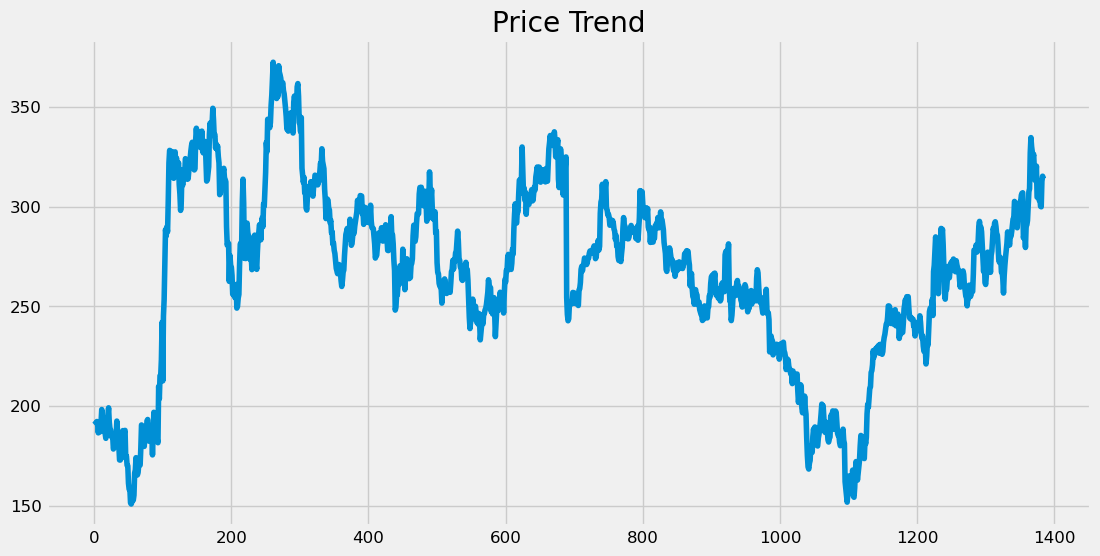

In [72]:
# Plot closing prices
df['Price'].plot(figsize=(12,6), title="Price Trend")
plt.show()



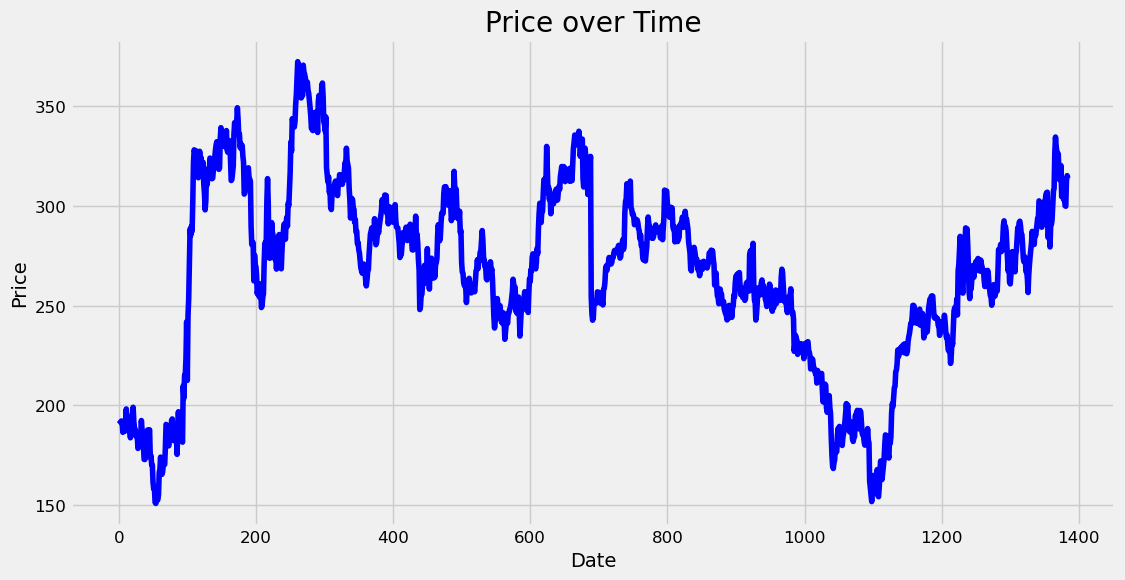

In [73]:
# Line plot for Price over time
plt.figure(figsize=(12,6))
plt.plot(df['Price'], color='blue')
plt.title("Price over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


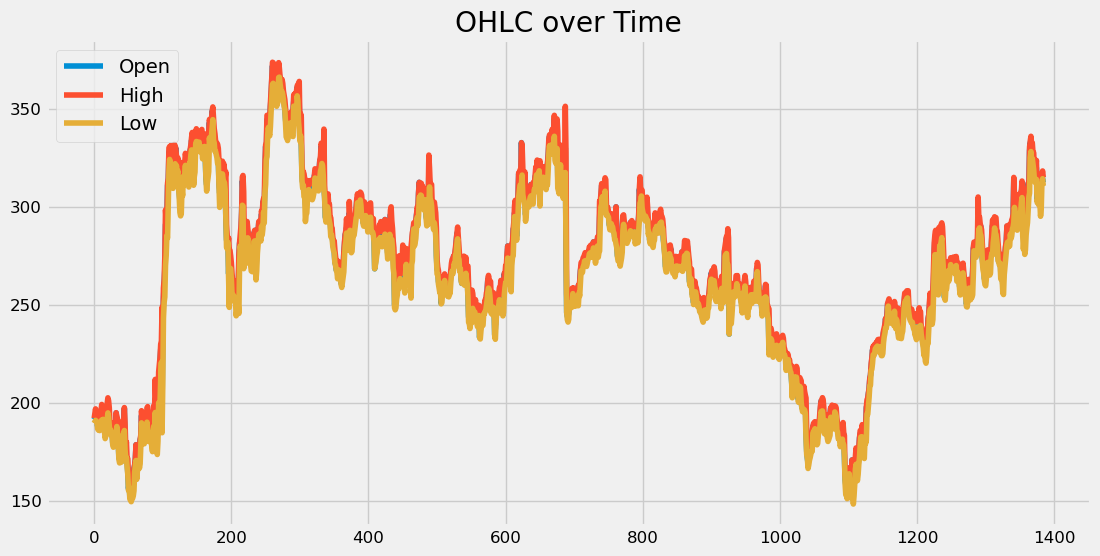

In [74]:
df[['Open','High','Low']].plot(figsize=(12,6))
plt.title("OHLC over Time")
plt.show()


In [75]:
adf_result = adfuller(df['Price'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

if adf_result[1] < 0.05:
    print("=> Series is Stationary (reject H0)")
else:
    print("=> Series is Non-Stationary (fail to reject H0)")


ADF Statistic: -2.6837345957216505
p-value: 0.07689543355657312
Critical Value (1%): -3.435
Critical Value (5%): -2.864
Critical Value (10%): -2.568
=> Series is Non-Stationary (fail to reject H0)


In [76]:
kpss_result = kpss(df['Price'], regression='c', nlags="auto")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
for key, value in kpss_result[3].items():
    print('Critical Value (%s): %.3f' % (key, value))

if kpss_result[1] < 0.05:
    print("=> Series is Non-Stationary (reject H0)")
else:
    print("=> Series is Stationary (fail to reject H0)")


KPSS Statistic: 0.7574604702936183
p-value: 0.01
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739
=> Series is Non-Stationary (reject H0)


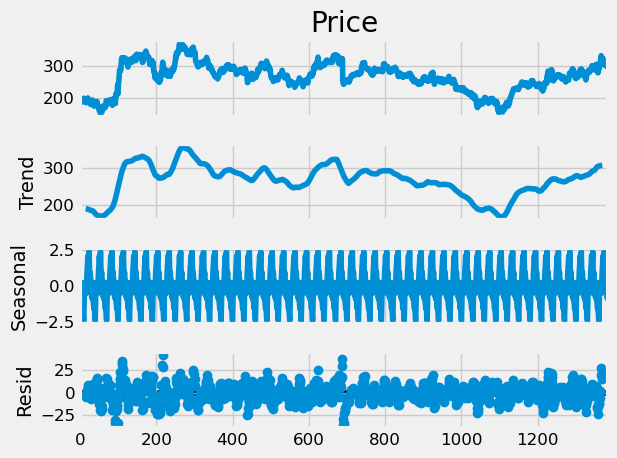

In [77]:
# Multiplicative or additive decomposition
decomposition = seasonal_decompose(df['Price'], model='additive', period=30) # period=30 for monthly seasonality if daily data

# Plot decomposition
decomposition.plot()
plt.show()

# Access individual components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


In [78]:
import itertools

# Define p, d, q ranges
p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

# Generate all combinations
pdq = list(itertools.product(p, d, q))

# Grid search to find best AIC
best_aic = np.inf
best_order = None

for order in pdq:
    try:
        model = ARIMA(df['Price'], order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
    except:
        continue

print("Best ARIMA parameters:", best_order)


Best ARIMA parameters: (2, 1, 3)


In [79]:
# Fit the model with best parameters
model = ARIMA(df['Price'], order=best_order)
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1385
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -4428.345
Date:                Fri, 24 Oct 2025   AIC                           8868.690
Time:                        12:35:58   BIC                           8900.086
Sample:                             0   HQIC                          8880.433
                               - 1385                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6103      0.073    -22.156      0.000      -1.753      -1.468
ar.L2         -0.8676      0.073    -11.916      0.000      -1.010      -0.725
ma.L1          1.6230      0.076     21.430      0.0

In [80]:
train_size = int(len(df) * 0.8)
train, test = df['Price'][:train_size], df['Price'][train_size:]

# Fit on train
model = ARIMA(train, order=best_order)
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))


In [81]:
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


MSE: 11878.97248264365
RMSE: 108.99069906484522


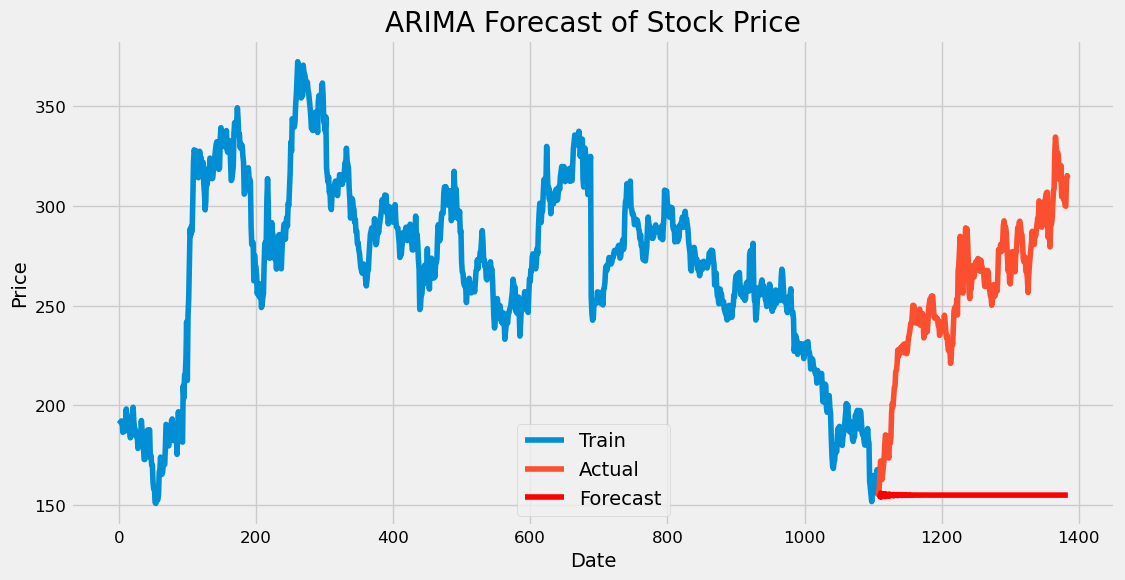

In [82]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title("ARIMA Forecast of Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()
